In [ ]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np

LOG.propagate = False

ble = get_ble_controller()
ble.connect()

In [ ]:
tof_log = []
imu_log = []

mode = None
done_flag = False

def tof_notification_handler(uuid, value):
    global tof_log, imu_log, mode, done_flag

    try:
        s = value.decode("utf-8").strip()
    except:
        s = str(value)

    print(s)

    if s == "DATA_IMU_TOF_STARTED":
        tof_log = []
        imu_log = []
        mode = None
        done_flag = False
        return

    if s.startswith("TOF,t_ms"):
        mode = "tof"
        return

    if s.startswith("IMU,t_ms"):
        mode = "imu"
        return

    if s.startswith("DONE"):
        done_flag = True
        return

    if mode == "tof":
        parts = s.split(",")
        if len(parts) == 3:
            t_ms = float(parts[0])
            front_mm = float(parts[1])
            right_mm = float(parts[2])
            tof_log.append([t_ms, front_mm, right_mm])

    elif mode == "imu":
        parts = s.split(",")
        if len(parts) == 3:
            t_ms = float(parts[0])
            pitch = float(parts[1])
            roll = float(parts[2])
            imu_log.append([t_ms, pitch, roll])

ble.start_notify(ble.uuid['RX_STRING'], tof_notification_handler)

ble.send_command(CMD.READ_IMU_TOF, "")

In [ ]:
import numpy as np

tof_data = np.array(tof_log)
imu_data = np.array(imu_log)

print("ToF shape:", tof_data.shape)
print("IMU shape:", imu_data.shape)

print("First 5 ToF rows:")
print(tof_data[:5])

In [ ]:
t_tof = tof_data[:, 0]
dt_tof = np.diff(t_tof)

print("Number of ToF samples:", len(t_tof))
print("Mean dt (ms):", np.mean(dt_tof))
print("Std dt (ms):", np.std(dt_tof))
print("Min dt (ms):", np.min(dt_tof))
print("Max dt (ms):", np.max(dt_tof))

freq_hz = 1000.0 / np.mean(dt_tof)
print("Estimated ToF frequency (Hz):", freq_hz)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(dt_tof, marker='o')
plt.xlabel("Sample index")
plt.ylabel("Inter-sample interval (ms)")
plt.title("ToF Sampling Interval")
plt.grid(True)
plt.show()

In [294]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [354]:
pid_log = []
pid_log_active = False
pid_log_done = False

def pid_notification_handler(uuid, value):
    global pid_log, pid_log_active, pid_log_done

    try:
        s = value.decode("utf-8").strip()
    except:
        s = str(value)

    print(s)

    if s == "PID_BEGIN":
        pid_log = []
        pid_log_active = True
        pid_log_done = False
        return

    if s.startswith("PID_END"):
        pid_log_active = False
        pid_log_done = True
        return

    if s.startswith("PID,") and pid_log_active:
        parts = s.split(",")
        if len(parts) == 8:
            t_ms = float(parts[1])
            raw_mm = float(parts[2])
            est_mm = float(parts[3])
            err_mm = float(parts[4])
            u_cmd = float(parts[5])
            left_pwm = float(parts[6])
            right_pwm = float(parts[7])
            # [time, raw distance, estimated distance, error, PID output, left PWM, right PWM]
            pid_log.append([t_ms, raw_mm, est_mm, err_mm, u_cmd, left_pwm, right_pwm])

ble.start_notify(ble.uuid['RX_STRING'], pid_notification_handler)

In [355]:
ble.send_command(CMD.SET_PID_GAINS, "0.04|0.0015|0.03")
ble.send_command(CMD.START_PID_LOG, "")

PID_GAINS,0.040,0.001,0.030
PID_LOG_STARTED
PID_LOG_AUTO_STOPPED


In [356]:
ble.send_command(CMD.SEND_PID_LOG, "")

PID_BEGIN
PID,2,2867.000,2867.000,2563.000,102.527,137,102
PID,625,2880.000,2880.000,2576.000,105.548,141,105
PID,641,2880.000,2880.333,2576.333,105.703,141,105
PID,647,2880.000,2880.458,2576.458,105.799,141,105
PID,652,2880.000,2880.563,2576.563,105.881,141,105
PID,669,2888.000,2888.000,2584.000,108.168,145,108
PID,674,2888.000,2888.909,2584.909,108.708,145,108
PID,680,2888.000,2890.000,2586.000,109.187,147,109
PID,687,2888.000,2891.272,2587.272,109.615,147,109
PID,692,2888.000,2892.181,2588.181,109.969,147,109
PID,698,2888.000,2893.272,2589.272,110.289,148,110
PID,703,2885.000,2885.000,2581.000,101.929,136,101
PID,709,2885.000,2884.470,2580.470,102.138,137,102
PID,719,2885.000,2883.588,2579.588,102.317,137,102
PID,725,2885.000,2883.058,2579.058,102.469,137,102
PID,730,2891.000,2891.000,2587.000,110.477,148,110
PID,741,2891.000,2893.444,2589.444,110.991,148,110
PID,750,2891.000,2895.444,2591.444,111.424,149,111
PID,761,2891.000,2897.888,2593.888,111.834,149,111
PID,772,2891.000,2900.3

In [357]:
pid_data = np.array(pid_log)

t = pid_data[:, 0]
raw_dist = pid_data[:, 1]
est_dist = pid_data[:, 2]
err = pid_data[:, 3]
u = pid_data[:, 4]

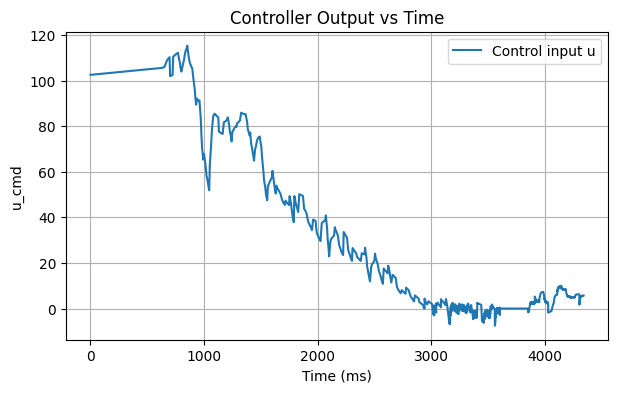

In [358]:
plt.figure(figsize=(7,4))
plt.plot(t, u, label="Control input u")
plt.xlabel("Time (ms)")
plt.ylabel("u_cmd")
plt.title("Controller Output vs Time")
plt.grid(True)
plt.legend()
plt.show()

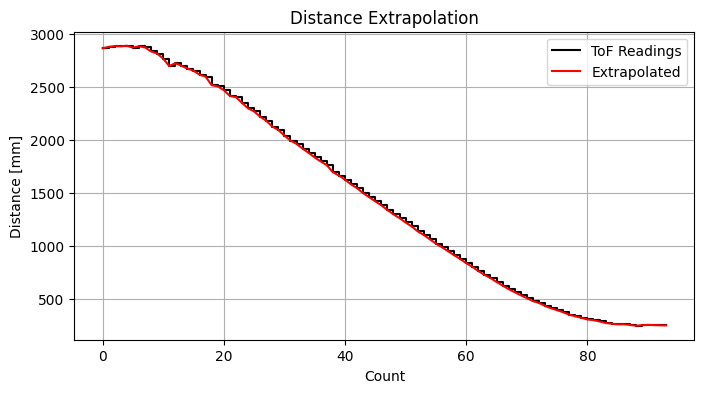

In [359]:
import numpy as np
import matplotlib.pyplot as plt

raw_dist = pid_data[:, 1]
est_dist = pid_data[:, 2]

# 只保留 raw 发生变化的点，更像 ToF 的阶梯图
keep = np.r_[True, np.diff(raw_dist) != 0]

raw_unique = raw_dist[keep]
est_unique = est_dist[keep]
count_unique = np.arange(len(raw_unique))

plt.figure(figsize=(8,4))
plt.step(count_unique, raw_unique, where="post", label="ToF Readings", color="black")
plt.plot(count_unique, est_unique, label="Extrapolated", color="red")
plt.xlabel("Count")
plt.ylabel("Distance [mm]")
plt.title("Distance Extrapolation")
plt.legend()
plt.grid(True)
plt.show()

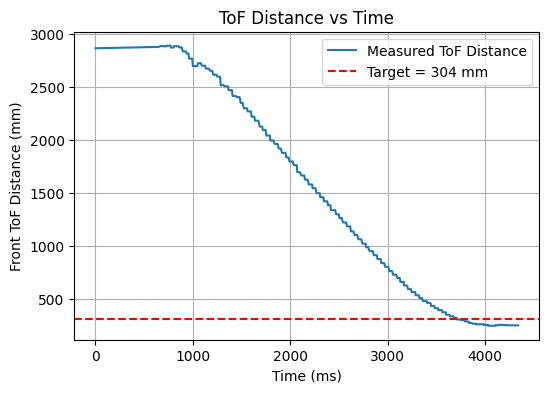

In [360]:
import matplotlib.pyplot as plt

t = pid_data[:, 0]
dist = pid_data[:, 1]

plt.figure(figsize=(6,4))
plt.plot(t, dist, label="Measured ToF Distance")
plt.axhline(y=304, linestyle="--", color="red", label="Target = 304 mm")

plt.xlabel("Time (ms)")
plt.ylabel("Front ToF Distance (mm)")
plt.title("ToF Distance vs Time")
plt.grid(True)
plt.legend()
plt.show()

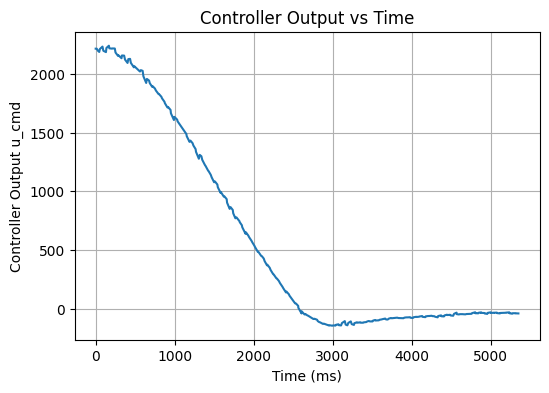

In [323]:
import matplotlib.pyplot as plt

t = pid_data[:, 0]
dist = pid_data[:, 1]
u_cmd = pid_data[:, 3]

plt.figure(figsize=(6,4))
plt.plot(t, u_cmd)
plt.xlabel("Time (ms)")
plt.ylabel("Controller Output u_cmd")
plt.title("Controller Output vs Time")
plt.grid(True)
plt.show()

In [ ]:
pid_rate_log = []
pid_rate_active = False
pid_rate_done = False

def pid_rate_notification_handler(uuid, value):
    global pid_rate_log, pid_rate_active, pid_rate_done

    try:
        s = value.decode("utf-8").strip()
    except:
        s = str(value)

    print(s)

    if s == "PID_RATE_BEGIN":
        pid_rate_log = []
        pid_rate_active = True
        pid_rate_done = False
        return

    if s.startswith("PID_RATE_END"):
        pid_rate_active = False
        pid_rate_done = True
        return

    if s.startswith("PR,") and pid_rate_active:
        parts = s.split(",")
        if len(parts) == 2:
            t_us = float(parts[1])
            pid_rate_log.append(t_us)

ble.start_notify(ble.uuid['RX_STRING'], pid_rate_notification_handler)

ble.send_command(CMD.START_PID_RATE_TEST, "")

In [ ]:
ble.send_command(CMD.SEND_PID_RATE_TEST, "")

In [173]:
import numpy as np

pid_rate_data = np.array(pid_rate_log)
dt_us = np.diff(pid_rate_data)

print("Number of PID samples:", len(pid_rate_data))
print("Mean dt (us):", np.mean(dt_us))
print("Std dt (us):", np.std(dt_us))
print("Min dt (us):", np.min(dt_us))
print("Max dt (us):", np.max(dt_us))

freq_hz = 1e6 / np.mean(dt_us)
print("Estimated PID loop frequency (Hz):", freq_hz)

Number of PID samples: 3314
Mean dt (us): 905.1273769996982
Std dt (us): 936.4457907750667
Min dt (us): 626.0
Max dt (us): 5640.0
Estimated PID loop frequency (Hz): 1104.8168748522269


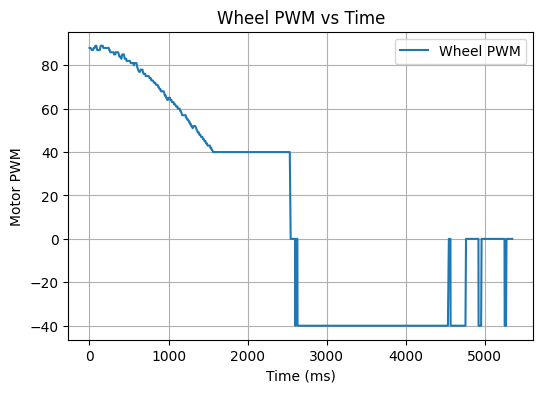

In [324]:
import matplotlib.pyplot as plt

t = pid_data[:, 0]
right_pwm = pid_data[:, 6]

plt.figure(figsize=(6,4))
plt.plot(t, right_pwm, label="Wheel PWM")
plt.xlabel("Time (ms)")
plt.ylabel("Motor PWM")
plt.title("Wheel PWM vs Time")
plt.grid(True)
plt.legend()
plt.show()